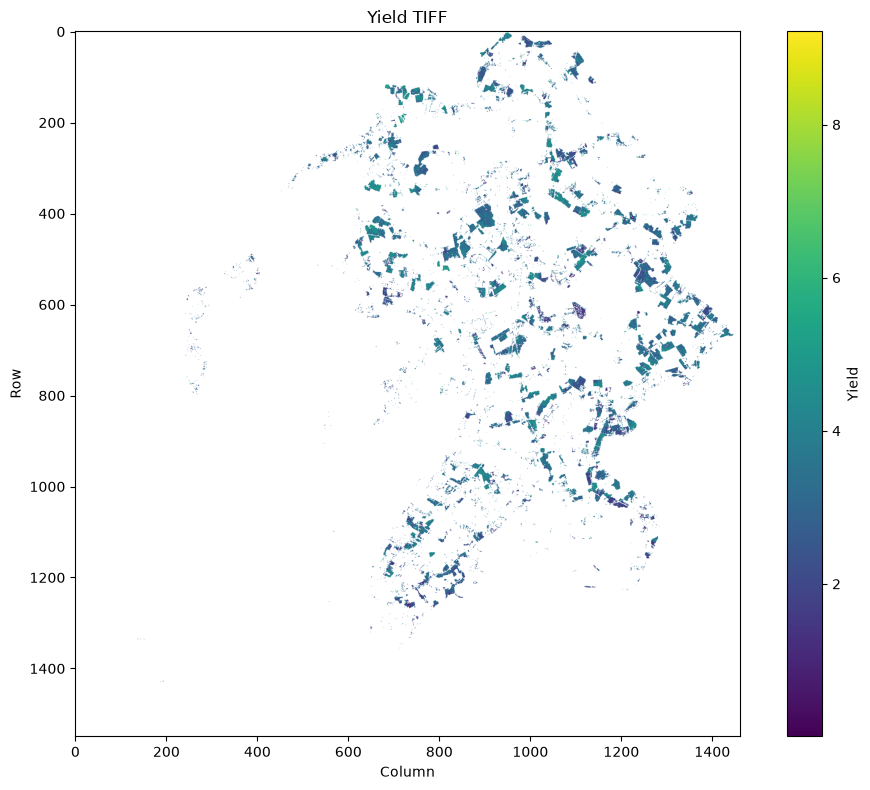

Available Layers:
Band 1: NDVI_mean
Band 2: EVI_mean
Band 3: GCVI_mean
Band 4: NDWI_mean
Band 5: NDVI_obsCount
Band 6: EVI_obsCount
Band 7: GCVI_obsCount
Band 8: NDWI_obsCount
Band 9: min_index_obsCount
Band 10: crop_mask
Band 11: valid_vi_mask


In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Give your TIFF file path here
tif_path = r'/home/cholab/LabMembers/Samar/EO-based-yield-prediction/data_preparation/outputs/county_vi_summary/pixel_vi_tifs/soybeans_MD_2019_24039_Somerset_vi_pixels_nasa_cmr_hls.tif'

# Read the TIFF file
with rasterio.open(tif_path) as src:
    data = src.read(3)          # read first band
    nodata = src.nodata

# Convert NoData values to NaN
data = data.astype(float)

if nodata is not None:
    data[data == nodata] = np.nan

# Optional: remove zero values if zero means missing data
data[data == 0] = np.nan

# Plot the TIFF
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap="viridis")
plt.colorbar(label="Yield")
plt.title("Yield TIFF")
plt.xlabel("Column")
plt.ylabel("Row")
plt.tight_layout()
plt.show()


with rasterio.open(tif_path) as src:
    # Get the names of all layers
    layer_names = src.descriptions
    
    # Print them out with their corresponding band index
    print("Available Layers:")
    for i, name in enumerate(layer_names, start=1):
        print(f"Band {i}: {name}")

===== All Layers in GPKG =====
0: selected_states_counties_2023

===== Layers where STATEFP == 18 =====

Layer: selected_states_counties_2023
Rows: 1382
Columns: ['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
FOUND: 92 matching features

===== Matching Layers =====
selected_states_counties_2023

No layer selected. Plotting first matching layer: selected_states_counties_2023

===== Selected Layer Details =====
Layer: selected_states_counties_2023
Matching rows: 92
CRS: EPSG:5070
Geometry types: <StringArray>
['MultiPolygon']
Length: 1, dtype: str
   STATEFP COUNTYFP  COUNTYNS  GEOID         GEOIDFQ     NAME        NAMELSAD  \
21      18      073  00450494  18073  0500000US18073   Jasper   Jasper County   
22      18      151  00450390  18151  0500000US18151  Steuben  Steuben County   
43      18      115  00450378  18115  0500000US181

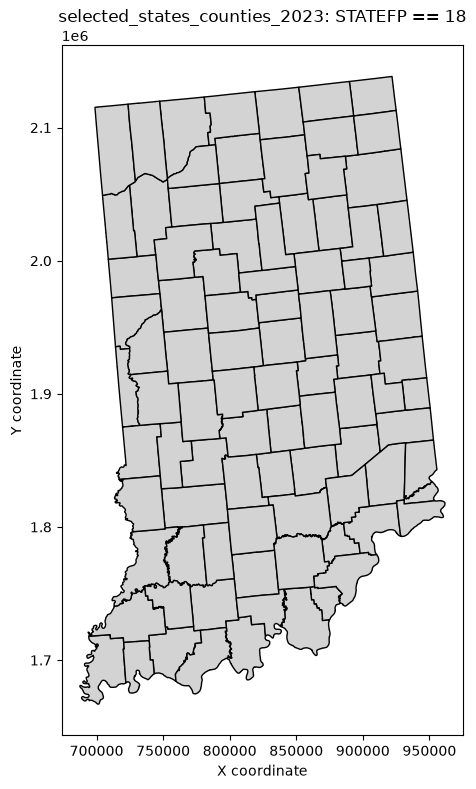

In [5]:
# ============================================================
# Read GPKG, find layers where COUNTYFP == 18, and plot them
# ============================================================

import geopandas as gpd
import fiona
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. Give your GPKG file path here
# ------------------------------------------------------------
gpkg_path = r"/Users/samarranjit/Library/CloudStorage/OneDrive-TexasStateUniversity/ChoLab/USDA Crop yield Stability Study/EO based yield prediction/data_preparation/data/counties/selected_states_counties_2023.gpkg"

# Column and value to filter
filter_column = "STATEFP"
filter_value = 18

# If you want to manually plot one matching layer, put its name here
# Otherwise, it will plot the first matching layer
layer_to_plot = None


# ------------------------------------------------------------
# 2. Check file exists
# ------------------------------------------------------------
gpkg_path = Path(gpkg_path)

if not gpkg_path.exists():
    raise FileNotFoundError(f"File not found: {gpkg_path}")


# ------------------------------------------------------------
# 3. List all layers
# ------------------------------------------------------------
layers = fiona.listlayers(gpkg_path)

print("===== All Layers in GPKG =====")
for i, layer in enumerate(layers):
    print(f"{i}: {layer}")
print()


# ------------------------------------------------------------
# 4. Check which layers have COUNTYFP == 18
# ------------------------------------------------------------
matching_layers = []

print(f"===== Layers where {filter_column} == {filter_value} =====")

for layer in layers:
    gdf = gpd.read_file(gpkg_path, layer=layer)

    print(f"\nLayer: {layer}")
    print(f"Rows: {len(gdf)}")
    print(f"Columns: {list(gdf.columns)}")

    if filter_column not in gdf.columns:
        print(f"'{filter_column}' column not found.")
        continue

    # Convert COUNTYFP to number, so values like "18" or "018" still work
    countyfp_numeric = pd.to_numeric(gdf[filter_column], errors="coerce")

    matches = gdf[countyfp_numeric == filter_value]

    if len(matches) > 0:
        print(f"FOUND: {len(matches)} matching features")
        matching_layers.append(layer)
    else:
        print("No matching features.")

print("\n===== Matching Layers =====")
if matching_layers:
    for layer in matching_layers:
        print(layer)
else:
    print("No layers found with COUNTYFP == 18.")


# ------------------------------------------------------------
# 5. Choose layer to plot
# ------------------------------------------------------------
if not matching_layers:
    raise ValueError(f"No layers found with {filter_column} == {filter_value}")

if layer_to_plot is None:
    layer_to_plot = matching_layers[0]
    print(f"\nNo layer selected. Plotting first matching layer: {layer_to_plot}")


# ------------------------------------------------------------
# 6. Read and filter selected layer
# ------------------------------------------------------------
gdf = gpd.read_file(gpkg_path, layer=layer_to_plot)

countyfp_numeric = pd.to_numeric(gdf[filter_column], errors="coerce")
gdf_match = gdf[countyfp_numeric == filter_value]

print("\n===== Selected Layer Details =====")
print(f"Layer: {layer_to_plot}")
print(f"Matching rows: {len(gdf_match)}")
print(f"CRS: {gdf_match.crs}")
print(f"Geometry types: {gdf_match.geometry.geom_type.unique()}")
print(gdf_match.head())


# ------------------------------------------------------------
# 7. Plot only features where COUNTYFP == 18
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

gdf_match.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray",
    linewidth=1
)

ax.set_title(f"{layer_to_plot}: {filter_column} == {filter_value}")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()

In [1]:
print("")

===== TIFF DETAILS =====
File: soybeans_DE_2020_pseudo_yield.tif
Width: 3085
Height: 5132
CRS: EPSG:5070
NoData: -9999.0
Bounds: BoundingBox(left=1704030.0, bottom=1901190.0, right=1796580.0, top=2055150.0)
Number of bands: 1
Band descriptions: ('pseudo_yield_bu_ac',)

===== TIFF DATA SUMMARY =====
Min: 37.14158248901367
Max: 63.25
Mean: 48.89179608603762
Valid pixels: 690585

===== GPKG LAYERS =====
0: selected_states_counties_2023

===== Layer: selected_states_counties_2023 =====
Rows: 1382
CRS: EPSG:5070
Columns: ['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
Geometry types: <StringArray>
['MultiPolygon']
Length: 1, dtype: str
Rows where STATEFP == 10: 3

Using layer: selected_states_counties_2023

===== SELECTED GPKG DATA =====
Layer: selected_states_counties_2023
Matching rows: 3
CRS: EPSG:5070
     STATEFP COUNTYFP  COUNTYNS  G

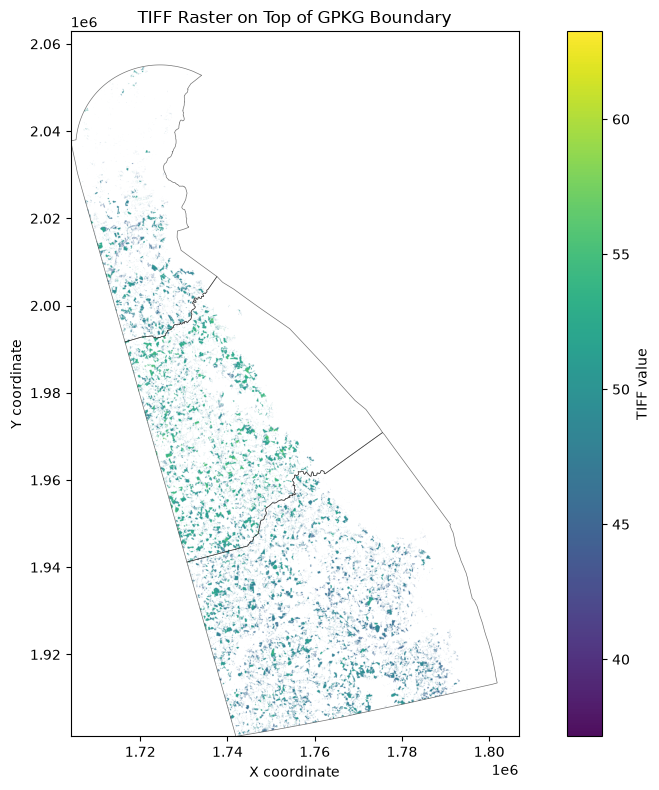

In [4]:
# ============================================================
# Read TIFF + GPKG and plot together
# GPKG plotted faintly, TIFF plotted clearly on top
# ============================================================

import rasterio
from rasterio.plot import plotting_extent
import geopandas as gpd
import fiona
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# 1. File paths
# ------------------------------------------------------------
tif_path = r"/home/cholab/LabMembers/Samar/EO-based-yield-prediction/data_preparation/data/pixel_distributed_yield/2020/soybeans_DE_2020_pseudo_yield.tif"

gpkg_path = r"/home/cholab/LabMembers/Samar/EO-based-yield-prediction/data_preparation/data/county_maps/selected_states_counties_2023.gpkg"


# ------------------------------------------------------------
# 2. GPKG filter settings
# ------------------------------------------------------------
filter_column = "STATEFP"
filter_value = 10

# Keep None to automatically use the first layer that matches
layer_to_plot = None


# ------------------------------------------------------------
# 3. Read TIFF
# ------------------------------------------------------------
with rasterio.open(tif_path) as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    raster_crs = src.crs
    raster_extent = plotting_extent(src)
    descriptions = src.descriptions

    print("===== TIFF DETAILS =====")
    print(f"File: {Path(tif_path).name}")
    print(f"Width: {src.width}")
    print(f"Height: {src.height}")
    print(f"CRS: {src.crs}")
    print(f"NoData: {src.nodata}")
    print(f"Bounds: {src.bounds}")
    print(f"Number of bands: {src.count}")
    print(f"Band descriptions: {descriptions}")
    print()

# Clean TIFF data
if nodata is not None:
    data[data == nodata] = np.nan

# Remove zeros if they mean no data
data[data == 0] = np.nan

# data = data / 67.25
data = data 

print("===== TIFF DATA SUMMARY =====")
print(f"Min: {np.nanmin(data)}")
print(f"Max: {np.nanmax(data)}")
print(f"Mean: {np.nanmean(data)}")
print(f"Valid pixels: {np.count_nonzero(~np.isnan(data))}")
print()


# ------------------------------------------------------------
# 4. Read GPKG layers and print details
# ------------------------------------------------------------
gpkg_path = Path(gpkg_path)

if not gpkg_path.exists():
    raise FileNotFoundError(f"GPKG file not found: {gpkg_path}")

layers = fiona.listlayers(gpkg_path)

print("===== GPKG LAYERS =====")
for i, layer in enumerate(layers):
    print(f"{i}: {layer}")
print()


matching_layers = []

for layer in layers:
    gdf = gpd.read_file(gpkg_path, layer=layer)

    print(f"===== Layer: {layer} =====")
    print(f"Rows: {len(gdf)}")
    print(f"CRS: {gdf.crs}")
    print(f"Columns: {list(gdf.columns)}")
    print(f"Geometry types: {gdf.geometry.geom_type.unique()}")

    if filter_column in gdf.columns:
        values_numeric = pd.to_numeric(gdf[filter_column], errors="coerce")
        matches = gdf[values_numeric == filter_value]

        print(f"Rows where {filter_column} == {filter_value}: {len(matches)}")

        if len(matches) > 0:
            matching_layers.append(layer)
    else:
        print(f"Column {filter_column} not found.")

    print()


# ------------------------------------------------------------
# 5. Choose matching layer
# ------------------------------------------------------------
if not matching_layers:
    raise ValueError(f"No layer found with {filter_column} == {filter_value}")

if layer_to_plot is None:
    layer_to_plot = matching_layers[0]

print(f"Using layer: {layer_to_plot}")
print()


# ------------------------------------------------------------
# 6. Read selected GPKG layer and filter it
# ------------------------------------------------------------
gdf = gpd.read_file(gpkg_path, layer=layer_to_plot)

values_numeric = pd.to_numeric(gdf[filter_column], errors="coerce")
gdf_match = gdf[values_numeric == filter_value]

print("===== SELECTED GPKG DATA =====")
print(f"Layer: {layer_to_plot}")
print(f"Matching rows: {len(gdf_match)}")
print(f"CRS: {gdf_match.crs}")
print(gdf_match.head())
print()


# ------------------------------------------------------------
# 7. Reproject GPKG to match TIFF CRS
# ------------------------------------------------------------
if gdf_match.crs != raster_crs:
    gdf_match = gdf_match.to_crs(raster_crs)
    print("Reprojected GPKG to match TIFF CRS.")
    print(f"New GPKG CRS: {gdf_match.crs}")
    print()


# ------------------------------------------------------------
# 8. Plot GPKG first, then TIFF on top
# ------------------------------------------------------------
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)   # makes NaN pixels transparent

fig, ax = plt.subplots(figsize=(10, 8))



# Plot TIFF on top
img = ax.imshow(
    data,
    cmap=cmap,
    extent=raster_extent,
    alpha=0.95
)

# Plot GPKG underneath with low opacity
gdf_match.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.55
)

plt.colorbar(img, ax=ax, label="TIFF value")

ax.set_title("TIFF Raster on Top of GPKG Boundary")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

plt.tight_layout()
# plt.savefig("tiff_gpkg_overlay_sample.pdf", dpi=900)
plt.show()


===== ALIGNMENT CHECK =====
Raster CRS: EPSG:5070
County CRS: PROJCS["NAD83 / Conus Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5070"]]
Raster bounds: (1396590.0, 1828470.0, 1802700.0, 2037750.0)
State bounds: (np.float64(1396620.8323963443), np.float64(1828497.495471307), np.float64(1802679.0996445294), np.float64(2037741.279010403))
Edge differences: {'left': np.float64(30.832396344281733), 'bottom': np.floa

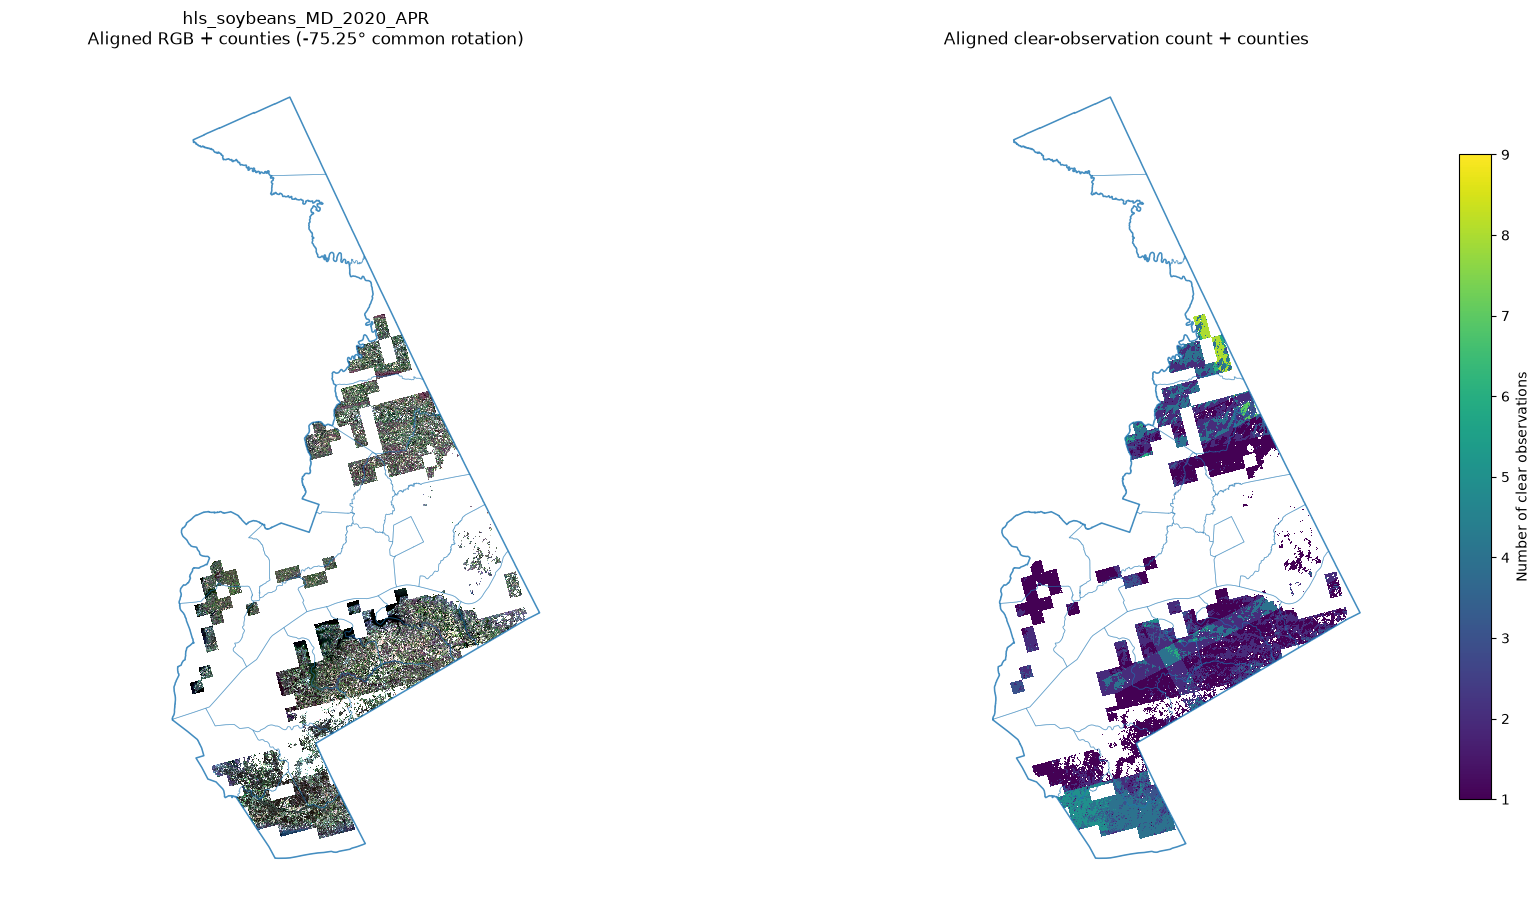

In [22]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.transforms import Affine2D
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
from rasterio.plot import plotting_extent
from shapely import affinity
from shapely.geometry import mapping

# ============================================================
# Configuration
# ============================================================
TIF_PATH = Path(
    "/home/cholab/LabMembers/Samar/EO-based-yield-prediction/data_preparation/outputs/HLS_Composites/2020/hls_soybeans_MD_2020_APR.tif"
)

GPKG_PATH = Path(
    "/home/cholab/LabMembers/Samar/EO-based-yield-prediction/"
    "data_preparation/data/county_maps/"
    "selected_states_counties_2023.gpkg"
)

STATE_FIPS = 24
HLS_SCALE = 0.0001
NODATA_THRESHOLD = -9990.0
MAX_DISPLAY_SIZE = 1800

# None estimates an upright display angle automatically.
# Use 0.0 to keep the native EPSG:5070 orientation.
DISPLAY_ROTATION_DEGREES = None

OUTPUT_PNG = TIF_PATH.with_name(
    TIF_PATH.stem + "_DE_counties_aligned.png"
)


def find_county_layer(path: Path) -> str:
    for layer in fiona.listlayers(path):
        with fiona.open(path, layer=layer) as src:
            if "STATEFP" in src.schema["properties"]:
                return layer
    raise ValueError("No GeoPackage layer containing STATEFP was found.")


def exterior_coordinates(geometry) -> np.ndarray:
    polygons = (
        [geometry]
        if geometry.geom_type == "Polygon"
        else list(geometry.geoms)
    )
    return np.vstack(
        [
            np.asarray(poly.exterior.coords, dtype=float)
            for poly in polygons
            if not poly.is_empty
        ]
    )


def estimate_rotation(geometry) -> float:
    xy = exterior_coordinates(geometry)
    centered = xy - xy.mean(axis=0)
    values, vectors = np.linalg.eigh(np.cov(centered.T))
    major_axis = vectors[:, np.argmax(values)]
    major_angle = np.degrees(
        np.arctan2(major_axis[1], major_axis[0])
    )

    rotation = 90.0 - major_angle

    while rotation > 90:
        rotation -= 180
    while rotation < -90:
        rotation += 180

    return float(rotation)


def rotate_points(points, angle_degrees, origin):
    angle = np.deg2rad(angle_degrees)
    matrix = np.array(
        [
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle), np.cos(angle)],
        ]
    )
    origin = np.asarray(origin, dtype=float)
    return (points - origin) @ matrix.T + origin


def rotated_extent(extent, angle_degrees, origin):
    left, right, bottom, top = extent
    corners = np.array(
        [
            [left, bottom],
            [left, top],
            [right, bottom],
            [right, top],
        ]
    )
    rotated = rotate_points(corners, angle_degrees, origin)
    return (
        rotated[:, 0].min(),
        rotated[:, 0].max(),
        rotated[:, 1].min(),
        rotated[:, 1].max(),
    )


# ============================================================
# Read and filter Delaware counties
# ============================================================
layer = find_county_layer(GPKG_PATH)
counties = gpd.read_file(GPKG_PATH, layer=layer)

statefp = pd.to_numeric(
    counties["STATEFP"],
    errors="coerce",
)

state_counties = counties[
    statefp == STATE_FIPS
].copy()

if state_counties.empty:
    raise ValueError("No Delaware counties were found.")


# ============================================================
# Read a display-resolution copy of the TIFF
# ============================================================
with rasterio.open(TIF_PATH) as src:
    if src.crs is None:
        raise ValueError("The TIFF does not have a CRS.")

    raster_crs = src.crs
    raster_bounds = src.bounds

    state_counties = state_counties.to_crs(raster_crs)
    state_outline = state_counties.dissolve()
    state_geometry = state_outline.geometry.iloc[0]

    scale = max(
        src.width / MAX_DISPLAY_SIZE,
        src.height / MAX_DISPLAY_SIZE,
        1.0,
    )

    display_width = max(
        1,
        int(round(src.width / scale)),
    )
    display_height = max(
        1,
        int(round(src.height / scale)),
    )

    data = src.read(
        [1, 2, 3, 7],
        out_shape=(
            4,
            display_height,
            display_width,
        ),
        resampling=rasterio.enums.Resampling.nearest,
    ).astype(np.float32)

    display_transform = (
        src.transform
        * src.transform.scale(
            src.width / display_width,
            src.height / display_height,
        )
    )

    extent = plotting_extent(
        data[0],
        display_transform,
    )


# ============================================================
# Exact state mask on the displayed raster grid
# ============================================================
state_mask = geometry_mask(
    [mapping(state_geometry)],
    out_shape=(display_height, display_width),
    transform=display_transform,
    invert=True,
    all_touched=False,
)

blue, green, red, observation_count = data

rgb_raw = np.stack(
    [red, green, blue],
    axis=-1,
)

valid_original = (
    np.all(np.isfinite(rgb_raw), axis=-1)
    & np.all(rgb_raw > NODATA_THRESHOLD, axis=-1)
    & (observation_count > 0)
)

inside_count = int(
    np.count_nonzero(valid_original & state_mask)
)

outside_count = int(
    np.count_nonzero(valid_original & ~state_mask)
)

state_bounds = state_outline.total_bounds

print("===== ALIGNMENT CHECK =====")
print(f"Raster CRS: {raster_crs}")
print(f"County CRS: {state_counties.crs}")
print(f"Raster bounds: {tuple(raster_bounds)}")
print(f"State bounds: {tuple(state_bounds)}")
print(
    "Edge differences:",
    {
        "left": state_bounds[0] - raster_bounds.left,
        "bottom": state_bounds[1] - raster_bounds.bottom,
        "right": raster_bounds.right - state_bounds[2],
        "top": raster_bounds.top - state_bounds[3],
    },
)
print(f"Displayed valid pixels inside Delaware:  {inside_count:,}")
print(f"Displayed valid pixels outside Delaware: {outside_count:,}")

# This is not a coordinate correction. It removes populated raster
# pixels that geographically fall outside Delaware.
valid = valid_original & state_mask
observation_count = np.where(
    state_mask,
    observation_count,
    0,
)


# ============================================================
# RGB visualization
# ============================================================
rgb = rgb_raw * HLS_SCALE
rgb_display = np.zeros_like(
    rgb,
    dtype=np.float32,
)

for channel in range(3):
    values = rgb[..., channel][valid]
    lower = np.percentile(values, 2)
    upper = np.percentile(values, 98)

    rgb_display[..., channel] = np.clip(
        (rgb[..., channel] - lower)
        / max(upper - lower, 1e-6),
        0,
        1,
    )

rgb_rgba = np.zeros(
    (*rgb_display.shape[:2], 4),
    dtype=np.float32,
)

rgb_rgba[..., :3] = rgb_display
rgb_rgba[..., 3] = valid.astype(np.float32)


# ============================================================
# One common display rotation for raster and vector
# ============================================================
rotation = (
    estimate_rotation(state_geometry)
    if DISPLAY_ROTATION_DEGREES is None
    else float(DISPLAY_ROTATION_DEGREES)
)

rotation_origin = (
    float(state_geometry.centroid.x),
    float(state_geometry.centroid.y),
)

rotated_counties = state_counties.copy()
rotated_counties.geometry = (
    rotated_counties.geometry.apply(
        lambda geometry: affinity.rotate(
            geometry,
            rotation,
            origin=rotation_origin,
            use_radians=False,
        )
    )
)

rotated_outline = rotated_counties.dissolve()

raster_left, raster_right, raster_bottom, raster_top = (
    rotated_extent(
        extent,
        rotation,
        rotation_origin,
    )
)

vector_left, vector_bottom, vector_right, vector_top = (
    rotated_outline.total_bounds
)

plot_left = min(raster_left, vector_left)
plot_right = max(raster_right, vector_right)
plot_bottom = min(raster_bottom, vector_bottom)
plot_top = max(raster_top, vector_top)

margin = 0.02 * max(
    plot_right - plot_left,
    plot_top - plot_bottom,
)

plot_left -= margin
plot_right += margin
plot_bottom -= margin
plot_top += margin


def raster_transform(axis):
    return (
        Affine2D().rotate_deg_around(
            rotation_origin[0],
            rotation_origin[1],
            rotation,
        )
        + axis.transData
    )


def add_boundaries(axis):
    rotated_counties.boundary.plot(
        ax=axis,
        linewidth=0.55,
        alpha=0.45,
        zorder=5,
    )

    rotated_outline.boundary.plot(
        ax=axis,
        linewidth=1.15,
        alpha=0.75,
        zorder=6,
    )

    axis.set_xlim(plot_left, plot_right)
    axis.set_ylim(plot_bottom, plot_top)
    axis.set_aspect("equal", adjustable="box")
    axis.axis("off")


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 9),
    constrained_layout=True,
)

axes[0].imshow(
    rgb_rgba,
    extent=extent,
    origin="upper",
    interpolation="nearest",
    transform=raster_transform(axes[0]),
    zorder=1,
)

add_boundaries(axes[0])

axes[0].set_title(
    f"{TIF_PATH.stem}\n"
    f"Aligned RGB + counties "
    f"({rotation:.2f}° common rotation)"
)

observation_display = np.ma.masked_where(
    observation_count <= 0,
    observation_count,
)

observation_cmap = plt.cm.viridis.copy()
observation_cmap.set_bad(alpha=0.0)

image = axes[1].imshow(
    observation_display,
    extent=extent,
    origin="upper",
    interpolation="nearest",
    cmap=observation_cmap,
    transform=raster_transform(axes[1]),
    zorder=1,
)

add_boundaries(axes[1])

axes[1].set_title(
    "Aligned clear-observation count + counties"
)

colorbar = fig.colorbar(
    image,
    ax=axes[1],
    shrink=0.76,
)

colorbar.set_label(
    "Number of clear observations"
)

fig.savefig(
    OUTPUT_PNG,
    dpi=250,
    bbox_inches="tight",
)

print(f"Saved: {OUTPUT_PNG}")

plt.show()